# 과제 - 신경망을 이용한 손글씨 숫자 인식



## 1. 환경설정



In [1]:
# Colab: 이 셀을 가장 먼저 실행하세요 (저장소 클론 후 경로·모듈 로드)
# 주의: Colab에서는 GitHub 저장소 URL과 Personal Access Token을 반드시 입력해야 합니다.
import os
import sys
from pathlib import Path

if "google.colab" in sys.modules:
    from getpass import getpass

    git_url = input("GitHub 저장소 URL (예: github.com/USERNAME/mnist-lab.git): ").strip()
    token = getpass("GitHub Personal Access Token (private 저장소인 경우): ")

    # URL 마지막 경로를 저장소 폴더명으로 사용합니다. (예: .../mnist-lab.git -> mnist-lab)
    repo_name = Path(git_url.rstrip("/")).name
    if repo_name.endswith(".git"):
        repo_name = repo_name[:-4]

    !git clone https://{token}@{git_url}
    os.chdir(repo_name)
    sys.path.insert(0, str(Path.cwd() / "src"))
else:
    sys.path.insert(0, "./src")


## 2. 데이터 로드

In [2]:
from data import load_mnist

(x_train, y_train), (x_test, y_test) = load_mnist()
print('Train:', x_train.shape, y_train.shape)
print('Test:', x_test.shape, y_test.shape)

Train: (60000, 784) (60000,)
Test: (10000, 784) (10000,)


Train Accuracy: 9.52%
Test Accuracy: 9.82%
Total Params: 537,354


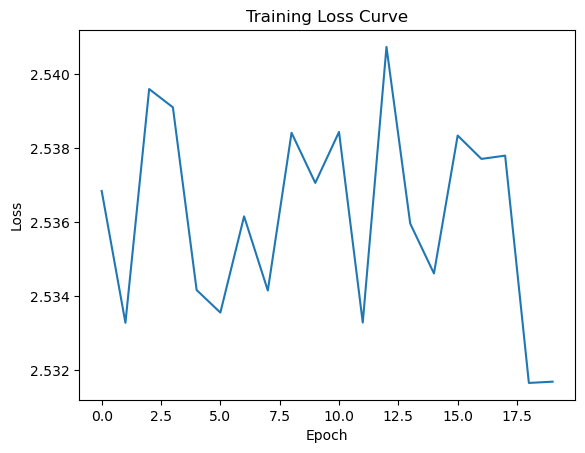

In [13]:
from training import evaluate, plot_loss_history

# acc, n_params = evaluate(model, x_test, y_test)

final_test_acc, n_params = evaluate(model, x_test, y_test)
final_train_acc, _ = evaluate(model, x_train, y_train)

# print(f'Test Accuracy: {acc:.2f}%')
print(f"Train Accuracy: {final_train_acc:.2f}%")
print(f"Test Accuracy: {final_test_acc:.2f}%")
print(f'Total Params: {n_params:,}')

plot_loss_history(loss_history)

In [10]:
# 저장된 모델 불러오기

import pickle
from network import NeuralNetwork
from optimizers import Adam, SGD

checkpoint_path = "saved_models/1500ep-mj.pkl" # 어느 모델을 불러올지 지정

with open(checkpoint_path, "rb") as f:
    checkpoint = pickle.load(f)

regularization = checkpoint.get("regularization", {})
training_config = checkpoint.get("training_config", {})
results = checkpoint.get("results", {})

use_batchnorm = regularization.get("use_batchnorm", False)
use_dropout = regularization.get("use_dropout", False)
dropout_ratio = regularization.get("dropout_ratio", None)

model = NeuralNetwork(
    use_batchnorm=use_batchnorm,
    use_dropout=use_dropout,
    dropout_ratio=dropout_ratio,
)

optimizer_name = training_config.get("optimizer", "Adam")
learning_rate = training_config.get("learning_rate", checkpoint["optimizer_state"]["lr"])

if optimizer_name == "Adam":
    optimizer = Adam(lr=learning_rate)
elif optimizer_name == "SGD":
    optimizer = SGD(lr=learning_rate)
else:
    raise ValueError(f"지원하지 않는 optimizer입니다: {optimizer_name}")

# 핵심: params dict를 통째로 바꾸지 말고, 기존 배열에 값만 복사
for key in model.params:
    model.params[key][...] = checkpoint["model_params"][key]

# optimizer 상태 복원
if optimizer_name == "Adam":
    optimizer.m = {k: v.copy() for k, v in checkpoint["optimizer_state"]["m"].items()}
    optimizer.v = {k: v.copy() for k, v in checkpoint["optimizer_state"]["v"].items()}
    optimizer

In [9]:
# 저장된 모델들 확인

import os
import glob
import pickle
import pandas as pd

model_files = sorted(glob.glob("saved_models/*.pkl"))
rows = []

for path in model_files:
    with open(path, "rb") as f:
        checkpoint = pickle.load(f)

    model_structure = checkpoint.get("model_structure", {})
    training_config = checkpoint.get("training_config", {})
    regularization = checkpoint.get("regularization", {})
    initialization = checkpoint.get("initialization", {})
    results = checkpoint.get("results", {})
    runtime = checkpoint.get("runtime", {})
    meta = checkpoint.get("meta", {})
    train_state = checkpoint.get("train_state", {})
    optimizer_state = checkpoint.get("optimizer_state", {})

    rows.append({
        "file_name": os.path.basename(path),

        # 모델 구조
        "num_hidden_layers": model_structure.get("num_hidden_layers"),
        "hidden_dims": str(model_structure.get("hidden_dims")),
        "input_dim": model_structure.get("input_dim"),
        "output_dim": model_structure.get("output_dim"),
        "activation": model_structure.get("activation"),

        # 학습 설정
        "optimizer": training_config.get("optimizer"),
        "learning_rate": training_config.get("learning_rate"),
        "epochs": training_config.get("epochs"),
        "batch_size": training_config.get("batch_size"),

        # 정규화·규제
        "use_batchnorm": regularization.get("use_batchnorm"),
        "use_dropout": regularization.get("use_dropout"),
        "dropout_ratio": regularization.get("dropout_ratio"),

        # 초기화
        "weight_init": initialization.get("weight_init"),

        # 결과
        "final_train_loss": results.get("final_train_loss"),
        "final_train_acc": results.get("final_train_acc"),
        "final_test_acc": results.get("final_test_acc"),
        "total_params": results.get("total_params"),

        # 학습 상태
        "saved_epoch": train_state.get("epoch"),
        "loss_history_len": len(train_state.get("loss_history", [])),

        # optimizer 상태
        "optimizer_lr": optimizer_state.get("lr"),
        "optimizer_step_t": optimizer_state.get("t"),

        # 시간 / 실행 환경
        "environment": runtime.get("environment"),
        "platform": runtime.get("platform"),
        "training_time_sec": runtime.get("training_time_sec"),
        "train_start_time": runtime.get("train_start_time"),
        "train_end_time": runtime.get("train_end_time"),

        # 메타
        "saved_at": meta.get("saved_at"),
    })

df = pd.DataFrame(rows)

# 보기 좋게 숫자 컬럼 정리
float_cols = [
    "learning_rate",
    "optimizer_lr",
    "final_train_loss",
    "final_train_acc",
    "final_test_acc",
    "training_time_sec",
]

for col in float_cols:
    if col in df.columns:
        df[col] = df[col].round(4)

# 전체 표
display(df)

# # 핵심 비교용 표
# summary_cols = [
#     "file_name",
#     "optimizer",
#     "learning_rate",
#     "epochs",
#     "batch_size",
#     "use_batchnorm",
#     "use_dropout",
#     "dropout_ratio",
#     "weight_init",
#     "final_train_loss",
#     "final_train_acc",
#     "final_test_acc",
#     "total_params",
#     "training_time_sec",
#     "saved_at",
# ]

# display(df[summary_cols])

,file_name,num_hidden_layers,hidden_dims,input_dim,output_dim,activation,optimizer,learning_rate,epochs,batch_size,...,saved_epoch,loss_history_len,optimizer_lr,optimizer_step_t,environment,platform,training_time_sec,train_start_time,train_end_time,saved_at
0,1500ep-mj.pkl,NaN,None,NaN,NaN,None,None,NaN,NaN,NaN,...,1500,1500,0.0010,900000,None,None,NaN,None,None,2026-05-26T13:18:54
1,20ep-adam-bn-dr02-yk.pkl,2.0,"[512, 256]",784.0,10.0,ReLU,Adam,0.0267,20.0,128.0,...,20,20,0.0267,9380,local,macOS-15.7.7-arm64-arm-64bit,239.0397,2026-05-26T16:34:06,2026-05-26T16:38:05,2026-05-26T16:38:05
2,20ep-adam-mj.pkl,2.0,"[512, 256]",784.0,10.0,ReLU,Adam,0.0267,20.0,128.0,...,20,20,0.0267,9380,local,Linux-6.17.0-29-generic-x86_64-with-glibc2.39,351.4041,2026-05-26T16:15:39,2026-05-26T16:21:31,2026-05-26T16:21:31
3,64ep-yk.pkl,NaN,None,NaN,NaN,None,None,NaN,NaN,NaN,...,1500,64,0.0267,38400,None,None,NaN,None,None,2026-05-26T13:35:31


In [7]:
# 제외할 파일명 지정

import glob
import os

excluded_files = {"1500ep-mj.pkl", "64ep-yk.pkl", "20ep-adam-mj.pkl",
    "20ep-adam-bn-dr02-yk.pkl",
    "20ep-adam-bn-dr03-lr0001-yk.pkl",
    "20ep-adam-bn-dr03-yk.pkl",
    "20ep-adam-bn-dr00-mj.pkl"
    }

model_files = [
    path for path in sorted(glob.glob("saved_models/*.pkl"))
    if os.path.basename(path) not in excluded_files
]

print([os.path.basename(path) for path in model_files])

['10.pkl', '20.pkl', '20ep-adam-nonebn-dr00-mj.pkl', '20ep-adam-nonebn-dr02-mj.pkl', '20ep-adam-nonebn-dr03-mj.pkl', 'test-adam-02-0001-ykt.pkl.pkl', 'test-adam-02-0005-ykt.pkl.pkl', 'test-adam-02-001-ykt.pkl.pkl', 'test-adam-03-0001-ykt.pkl.pkl', 'test-adam-03-0005-ykt.pkl.pkl', 'test-adam-03-001-ykt.pkl.pkl', 'test-adam-05-0001-ykt.pkl.pkl', 'test-adam-05-0005-ykt.pkl.pkl', 'test-adam-05-001-ykt.pkl.pkl', 'test-adam-sig-ykt.pkl']


# 학습 자동화

In [63]:
from network import NeuralNetwork
from optimizers import Adam
from training import train
from optimizers import SGD
from datetime import datetime
from training import evaluate, plot_loss_history

import os
import pickle
import platform
from datetime import datetime

""" 
    HYPTERPATRAMETER CONFIGURATION START
"""
# (0           , 1 , 2     , 3      , 4   , 5  )
# (dropout_rate, lr, epochs, use_bat, name, dir)
test_configs = [
    # (0, 0.001, 10, True, 'test-epchos-10', 'model_epchos'),
    # (0, 0.001, 20, True, 'test-epchos-20', 'model_epchos'),
    # (0, 0.001, 30, True, 'test-epchos-30', 'model_epchos'),
    # (0, 0.001, 40, True, 'test-epchos-40', 'model_epchos'),
    # (0, 0.001, 50, True, 'test-epchos-50', 'model_epchos'),

    # (0, 0.001,  20, True, 'test-lr-10', 'model_lr'),
    # (0, 0.0005, 20, True, 'test-lr-05', 'model_lr'),
    # (0, 0.0001, 20, True, 'test-lr-01', 'model_lr'),

    # (0,   0.001, 20, False, 'test-bat-f-nd', 'model_bat'),
    # (0.2, 0.001, 20, False, 'test-bat-f-02', 'model_bat'),
    # (0.3, 0.001, 20, False, 'test-bat-f-03', 'model_bat'),

    # (0,   0.001, 20, True, 'test-bat-t-nd', 'model_bat'),
    # (0.2, 0.001, 20, True, 'test-bat-t-02', 'model_bat'),
    # (0.3, 0.001, 20, True, 'test-bat-t-03', 'model_bat'),
    
    # (0, 0.001, 5,  False, 'test-epchos-5',  'model_epochs_2'),
    # (0, 0.001, 20, False, 'test-epchos-20', 'model_epochs_2'),
    # (0, 0.001, 40, False, 'test-epchos-40', 'model_epochs_2'),
    # (0, 0.001, 80, False, 'test-epchos-80', 'model_epochs_2'),
    # (0, 0.001, 160, False, 'test-epchos-160', 'model_epochs_2'),

    (0, 0.0001, 5,  False, 'test-epchos-5',  'model_epochs_3'),
]

tmp_configs = []
for config in test_configs:
    for index in range(1, 3+1):
        fname = config[4]+'-'+str(index)
        # print(fname)
        tmp_row = list(config)
        tmp_row[4] = fname
        tmp_configs.append(tuple(tmp_row))
test_configs = tmp_configs

""" 
    HYPTERPATRAMETER CONFIGURATION END
"""


total_loss_histroy = []

# Iterate
for test_config in test_configs:
    # hyperparameters

    batchnorm = test_config[3]
    dropout = False if test_config[0] == 0 else True
    dropout_rt = test_config[0]
    epochs = test_config[2]
    lr = test_config[1]
    bat_size = 128

    model = NeuralNetwork(use_batchnorm=batchnorm, use_dropout=dropout)  # BatchNorm, Dropout 필수
    optimizer = Adam(lr=lr)


    # 실제 학습
    train_start_time = datetime.now()
    loss_history = train(model, optimizer, x_train, y_train, epochs=epochs, batch_size=bat_size)
    train_end_time = datetime.now()
    total_loss_histroy.append(loss_history)

    final_test_acc, n_params = evaluate(model, x_test, y_test)
    final_train_acc, _ = evaluate(model, x_train, y_train)

    # 모델 저장

    os.makedirs(test_config[5], exist_ok=True) # TODO: dir 변경

    current_epoch = len(loss_history)
    model_name = test_config[4]  # 원하는 이름으로 변경 가능

    # 아래 값들은 학습 셀에서 실제로 사용한 값과 맞춰주기
    hidden_dims = [512, 256]
    activation = "ReLU"
    optimizer_name = type(optimizer).__name__
    learning_rate = optimizer.lr
    batch_size = bat_size
    use_batchnorm = batchnorm
    use_dropout = dropout
    dropout_ratio = dropout_rt
    weight_init = "He"

    # 학습 시간
    # 학습 시작 전에 train_start_time = datetime.now() 같은 방식으로 기록해두었다고 가정
    # 아직 없다면 우선 None으로 저장 가능
    train_start_time_str = train_start_time.isoformat(timespec="seconds") if "train_start_time" in globals() else None

    train_end_time_str = train_end_time.isoformat(timespec="seconds")
    training_time_sec = (train_end_time - train_start_time).total_seconds() if "train_start_time" in globals() else None

    total_params = sum(p.size for p in model.params.values())

    checkpoint = {
        "model_params": {k: v.copy() for k, v in model.params.items()},
        "optimizer_state": {
            "m": {k: v.copy() for k, v in optimizer.m.items()},
            "v": {k: v.copy() for k, v in optimizer.v.items()},
            "t": optimizer.t,
            "lr": optimizer.lr,
        },
        "model_structure": {
            "num_hidden_layers": len(hidden_dims),
            "hidden_dims": hidden_dims,
            "input_dim": 784,
            "output_dim": 10,
            "activation": activation,
        },
        "training_config": {
            "optimizer": optimizer_name,
            "learning_rate": learning_rate,
            "epochs": current_epoch,
            "batch_size": batch_size,
        },
        "regularization": {
            "use_batchnorm": use_batchnorm,
            "use_dropout": use_dropout,
            "dropout_ratio": dropout_ratio,
        },
        "initialization": {
            "weight_init": weight_init,
        },
        "train_state": {
            "epoch": current_epoch,
            "loss_history": list(loss_history),
        },
        "results": {
            "final_train_loss": float(loss_history[-1]) if len(loss_history) > 0 else None,
            "final_train_acc": float(final_train_acc),
            "final_test_acc": float(final_test_acc),
            "total_params": int(total_params),
        },
        "runtime": {
            "environment": "colab" if "google.colab" in str(type(get_ipython())) else "local",
            "platform": platform.platform(),
            "train_start_time": train_start_time_str,
            "train_end_time": train_end_time_str,
            "training_time_sec": training_time_sec,
        },
        "meta": {
            "saved_at": datetime.now().isoformat(timespec="seconds"),
        },
    }

    checkpoint_path = f"{test_config[5]}/{model_name}.pkl"

    with open(checkpoint_path, "wb") as f:
        pickle.dump(checkpoint, f)

    print(f"saved: {checkpoint_path}")

saved: model_epochs_3/test-epchos-5-1.pkl
saved: model_epochs_3/test-epchos-5-2.pkl
saved: model_epochs_3/test-epchos-5-3.pkl


In [27]:
test_configs = [
    (0, 0.001, 10, True, 'test-epchos-10', 'model_epchos'),
    (0, 0.001, 20, True, 'test-epchos-20', 'model_epchos'),
    (0, 0.001, 30, True, 'test-epchos-30', 'model_epchos'),
    (0, 0.001, 40, True, 'test-epchos-40', 'model_epchos'),
    (0, 0.001, 50, True, 'test-epchos-50', 'model_epchos'),

    (0, 0.001,  20, True, 'test-lr-10', 'model_lr'),
    (0, 0.0005, 20, True, 'test-lr-05', 'model_lr'),
    (0, 0.0001, 20, True, 'test-lr-01', 'model_lr'),

    (0,   0.001, 20, False, 'test-bat-f-nd', 'model_bat'),
    (0.2, 0.001, 20, False, 'test-bat-f-02', 'model_bat'),
    (0.3, 0.001, 20, False, 'test-bat-f-03', 'model_bat'),

    (0,   0.001, 20, True, 'test-bat-t-nd', 'model_bat'),
    (0.2, 0.001, 20, True, 'test-bat-t-02', 'model_bat'),
    (0.3, 0.001, 20, True, 'test-bat-t-03', 'model_bat'),
]

tmp_configs = []
for config in test_configs:
    for index in range(1, 3+1):
        fname = config[4]+'-'+str(index)
        # print(fname)
        tmp_row = list(config)
        tmp_row[4] = fname
        tmp_configs.append(tuple(tmp_row))
test_configs = tmp_configs
for config in test_configs: print(config)

(0, 0.001, 10, True, 'test-epchos-10-1', 'model_epchos')
(0, 0.001, 10, True, 'test-epchos-10-2', 'model_epchos')
(0, 0.001, 10, True, 'test-epchos-10-3', 'model_epchos')
(0, 0.001, 20, True, 'test-epchos-20-1', 'model_epchos')
(0, 0.001, 20, True, 'test-epchos-20-2', 'model_epchos')
(0, 0.001, 20, True, 'test-epchos-20-3', 'model_epchos')
(0, 0.001, 30, True, 'test-epchos-30-1', 'model_epchos')
(0, 0.001, 30, True, 'test-epchos-30-2', 'model_epchos')
(0, 0.001, 30, True, 'test-epchos-30-3', 'model_epchos')
(0, 0.001, 40, True, 'test-epchos-40-1', 'model_epchos')
(0, 0.001, 40, True, 'test-epchos-40-2', 'model_epchos')
(0, 0.001, 40, True, 'test-epchos-40-3', 'model_epchos')
(0, 0.001, 50, True, 'test-epchos-50-1', 'model_epchos')
(0, 0.001, 50, True, 'test-epchos-50-2', 'model_epchos')
(0, 0.001, 50, True, 'test-epchos-50-3', 'model_epchos')
(0, 0.001, 20, True, 'test-lr-10-1', 'model_lr')
(0, 0.001, 20, True, 'test-lr-10-2', 'model_lr')
(0, 0.001, 20, True, 'test-lr-10-3', 'model_lr'

test-epchos-160-1.pkl
98.64
test-epchos-160-2.pkl
98.66
test-epchos-160-3.pkl
98.6
test-epchos-20-1.pkl
98.28
test-epchos-20-2.pkl
98.26
test-epchos-20-3.pkl
98.28
test-epchos-40-1.pkl
98.42
test-epchos-40-2.pkl
98.16
test-epchos-40-3.pkl
98.39
test-epchos-5-1.pkl
97.87
test-epchos-5-2.pkl
97.99
test-epchos-5-3.pkl
97.78999999999999
test-epchos-80-1.pkl
98.68
test-epchos-80-2.pkl
98.68
test-epchos-80-3.pkl
98.57000000000001


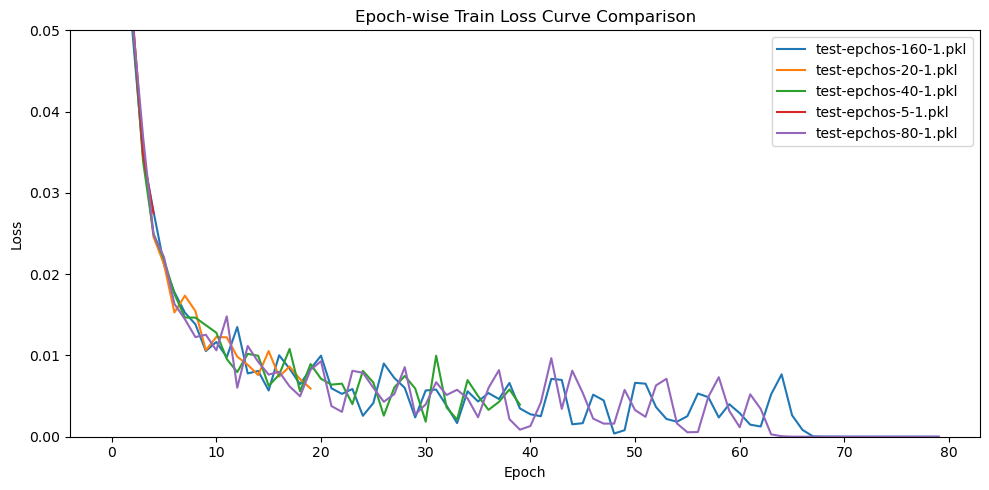

In [ ]:
# 모델 간 epoch별 train loss 변화
# "훈련 과정에서 어느 쪽이 더 빨리 / 더 낮게 loss를 줄였는가"

import os
import glob
import pickle
import matplotlib.pyplot as plt

excluded_files = []

dir_names = ['model_bat', 'model_epchos', 'model_lr', 'model_epochs_2']

model_files = [
    path for path in sorted(glob.glob(f"{dir_names[3]}/*.pkl"))
    if os.path.basename(path) not in excluded_files
]

plt.figure(figsize=(10, 5))

flag = False

for path in model_files:
    with open(path, "rb") as f:
        checkpoint = pickle.load(f)

    loss_history = checkpoint.get("train_state", {}).get("loss_history", [])
    print(os.path.basename(path))
    if not flag:
        print(checkpoint.get('results').get('final_test_acc'))
        # flag = True
    if len(loss_history) > 0 and str(os.path.basename(path))[-5] == '1':
        plt.plot(loss_history[:80], label=os.path.basename(path))

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Epoch-wise Train Loss Curve Comparison")
plt.legend()
plt.ylim(0, 0.05)
plt.tight_layout()
plt.show()

# train acc vs test acc

# for path in model_files:
#     with open(path, "rb") as f:
#         checkpoint = pickle.load(f)
#     train_acc: float = checkpoint.get('results').get('final_train_acc')
#     test_acc: float = checkpoint.get('results').get('final_test_acc')



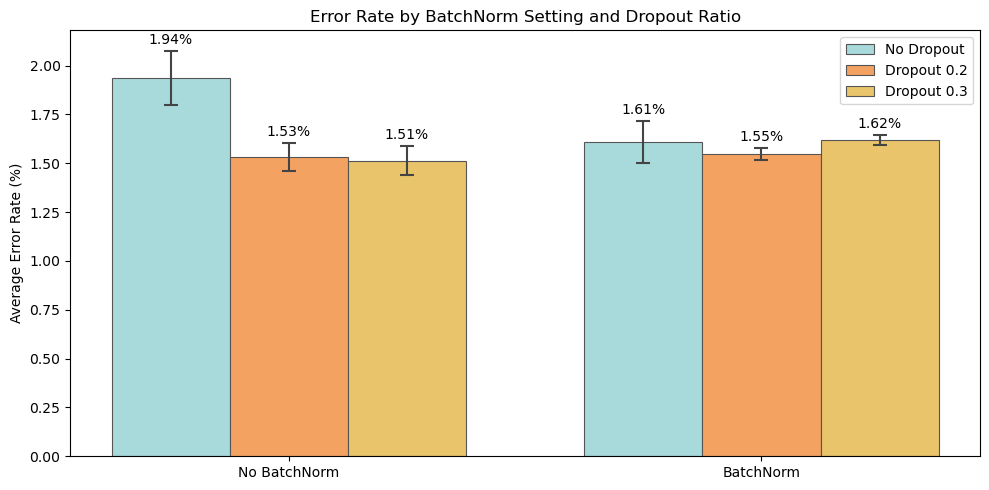

In [43]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

group_to_errors = {
    "No BatchNorm": {"No Dropout": [], "Dropout 0.2": [], "Dropout 0.3": []},
    "BatchNorm": {"No Dropout": [], "Dropout 0.2": [], "Dropout 0.3": []},
}

bn_dr_model_files = [
    path for path in sorted(glob.glob("model_bat/*.pkl"))
    if os.path.basename(path) not in excluded_files
]


for path in bn_dr_model_files:
    with open(path, "rb") as f:
        ckpt = pickle.load(f)

    if "regularization" not in ckpt or "results" not in ckpt:
        continue

    reg = ckpt["regularization"]
    acc = ckpt["results"].get("final_test_acc")

    if acc is None:
        continue

    use_batchnorm = reg.get("use_batchnorm", False)
    use_dropout = reg.get("use_dropout", False)
    dropout_ratio = reg.get("dropout_ratio", None)

    batchnorm_label = "BatchNorm" if use_batchnorm else "No BatchNorm"

    if not use_dropout:
        dropout_label = "No Dropout"
    elif dropout_ratio == 0.2:
        dropout_label = "Dropout 0.2"
    elif dropout_ratio == 0.3:
        dropout_label = "Dropout 0.3"
    else:
        continue

    error_rate = 100 - acc
    group_to_errors[batchnorm_label][dropout_label].append(error_rate)

def mean_std(values):
    if not values:
        return 0, 0
    if len(values) == 1:
        return np.mean(values), 0
    return np.mean(values), np.std(values, ddof=1)

x = np.arange(2)
width = 0.25

no_dropout_mean = []
no_dropout_std = []
dropout_02_mean = []
dropout_02_std = []
dropout_03_mean = []
dropout_03_std = []

for bn_label in ["No BatchNorm", "BatchNorm"]:
    m, s = mean_std(group_to_errors[bn_label]["No Dropout"])
    no_dropout_mean.append(m)
    no_dropout_std.append(s)

    m, s = mean_std(group_to_errors[bn_label]["Dropout 0.2"])
    dropout_02_mean.append(m)
    dropout_02_std.append(s)

    m, s = mean_std(group_to_errors[bn_label]["Dropout 0.3"])
    dropout_03_mean.append(m)
    dropout_03_std.append(s)
plt.figure(figsize=(10, 5))

bars1 = plt.bar(
    x - width,
    no_dropout_mean,
    width,
    yerr=no_dropout_std,
    capsize=5,
    label="No Dropout",
    color=pastel_colors[0],
    edgecolor="#555555",
    linewidth=0.8,
    error_kw={
        "ecolor": errorbar_color,
        "elinewidth": 1.5,
        "capthick": 1.5,
    },
)

bars2 = plt.bar(
    x,
    dropout_02_mean,
    width,
    yerr=dropout_02_std,
    capsize=5,
    label="Dropout 0.2",
    color=pastel_colors[1],
    edgecolor="#555555",
    linewidth=0.8,
    error_kw={
        "ecolor": errorbar_color,
        "elinewidth": 1.5,
        "capthick": 1.5,
    },
)

bars3 = plt.bar(
    x + width,
    dropout_03_mean,
    width,
    yerr=dropout_03_std,
    capsize=5,
    label="Dropout 0.3",
    color=pastel_colors[2],
    edgecolor="#555555",
    linewidth=0.8,
    error_kw={
        "ecolor": errorbar_color,
        "elinewidth": 1.5,
        "capthick": 1.5,
    },
)

# 막대 위에 평균 Error Rate 표시
def add_value_labels(bars, means, stds):
    for bar, mean, std in zip(bars, means, stds):
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + std + 0.02,   # error bar 위에 표시되도록 조정
            f"{mean:.2f}%",
            ha="center",
            va="bottom",
            fontsize=10,
        )

add_value_labels(bars1, no_dropout_mean, no_dropout_std)
add_value_labels(bars2, dropout_02_mean, dropout_02_std)
add_value_labels(bars3, dropout_03_mean, dropout_03_std)

plt.xticks(x, ["No BatchNorm", "BatchNorm"])
plt.ylabel("Average Error Rate (%)")
plt.title("Error Rate by BatchNorm Setting and Dropout Ratio")
plt.legend()
plt.tight_layout()
plt.show()

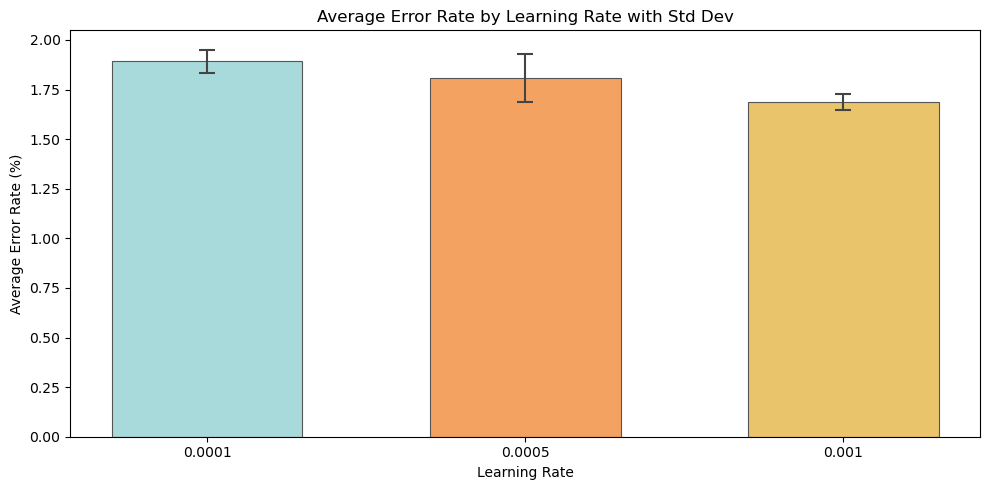

In [37]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

# 그래프 크기 조절
fig_width = 10
fig_height = 5

# 파스텔 톤 색상 팔레트
pastel_colors = [
    "#A8DADC",  # pastel cyan
    "#F4A261",  # pastel orange
    "#E9C46A",  # pastel yellow
    "#B8E0D2",  # pastel mint
    "#F7B2BD",  # pastel pink
    "#CDB4DB",  # pastel purple
    "#BDE0FE",  # pastel blue
    "#D8E2DC",  # pastel gray-green
    "#FFCAD4",  # soft rose
    "#CDEAC0",  # pastel green
]

errorbar_color = "#444444"

lr_to_errors = {}

bn_dr_model_files = [
    path for path in sorted(glob.glob("model_lr/*.pkl"))
    if os.path.basename(path) not in excluded_files
]

for path in bn_dr_model_files:
    with open(path, "rb") as f:
        ckpt = pickle.load(f)

    if "training_config" not in ckpt or "results" not in ckpt:
        continue

    lr = ckpt["training_config"].get("learning_rate")
    acc = ckpt["results"].get("final_test_acc")

    if lr is None or acc is None:
        continue

    error = 100 - acc

    if lr not in lr_to_errors:
        lr_to_errors[lr] = []
    lr_to_errors[lr].append(error)

labels = []
means = []
stds = []

for lr in sorted(lr_to_errors):
    errors = lr_to_errors[lr]

    labels.append(str(lr))
    means.append(np.mean(errors))

    if len(errors) > 1:
        stds.append(np.std(errors, ddof=1))
    else:
        stds.append(0)

# 막대 개수만큼 색상 반복/확장
colors = [
    pastel_colors[i % len(pastel_colors)]
    for i in range(len(labels))
]

plt.figure(figsize=(fig_width, fig_height))

plt.bar(
    labels,
    means,
    yerr=stds,
    capsize=6,
    color=colors,
    edgecolor="#555555",
    width=0.6,
    linewidth=0.8,
    error_kw={
        "ecolor": errorbar_color,
        "elinewidth": 1.5,
        "capthick": 1.5,
    }
)

plt.xlabel("Learning Rate")
plt.ylabel("Average Error Rate (%)")
plt.title("Average Error Rate by Learning Rate with Std Dev")
plt.tight_layout()
plt.show()